# **Project Part 1: YOLOv3**

Slides: [Google slide](https://docs.google.com/presentation/d/1CvQ1aq5LrImusv2QyhMOJkJovM6WooTVRXGhuN6opuE/)

Supplementary Information: [Google slide](https://docs.google.com/presentation/d/156K25Uwx_vkoDmLIzjFvL2RBRLKCh-GPz9WDxALKSKI/)

Video: [Youtube](https://youtu.be/gy9BXmGg894)

Objectives:
* Use YOLOv3 to practice the object detection task.
* Get familiar with PyTorch & YOLOv3.

If any questions, please contact the TA via email:
* Hung-Shuo Chang: jonathanc@iis.sinica.edu.tw

This notebook:

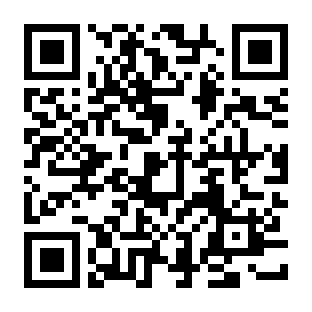

## **Introduction**

YOLO is a series of real-time object detection method.

YOLOv3 ([paper](https://arxiv.org/pdf/1804.02767.pdf)):
1. Anchor Based
2. Darknet-53
3. Feature Pyramid Networks (FPN)



### **Darknet-53**

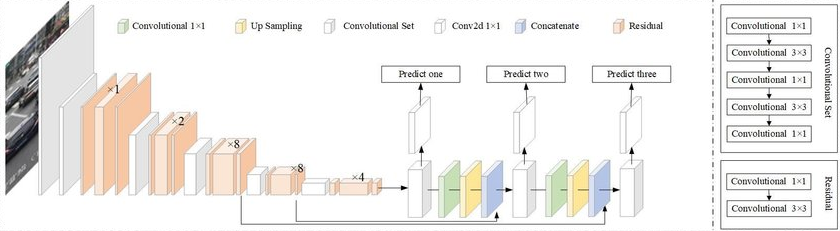

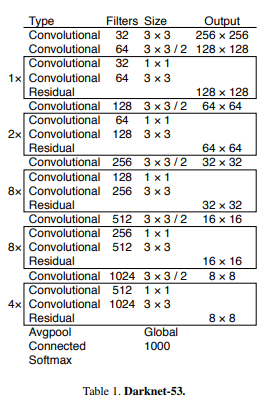

# **Environment Checking**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# [修改點 1] 雲端備份設定 + 命名策略
# [TRY-修改] 僅改 EXP_TAG 一行，其餘逐字同原檔；新實驗請先設 NEW_EXP=1 跑一次開新 EXP_NAME

import os
import re
from datetime import datetime, timezone, timedelta
from pathlib import Path

# 每次實驗的標籤（可手動改，建議含模型_尺寸_epoch）---
# [TRY3] EXP_TAG 改由 $EXP_YAML 實驗檔驅動（單一來源）；未設定時用下方字面預設值（重放從 run1/e12 開始）
_EXP_YAML = os.environ.get("EXP_YAML", "")
if _EXP_YAML and Path(_EXP_YAML).exists():
    import yaml as _yaml
    EXP_TAG = str(_yaml.safe_load(open(_EXP_YAML, encoding="utf-8"))["exp"])
else:
    EXP_TAG = "car_640_e12"
DRIVE_ROOT = "/content/drive/MyDrive/YOLO_Experiments"
SAFE_TAG = re.sub(r"[^A-Za-z0-9_.-]+", "_", EXP_TAG).strip("._") or "exp"
NAME_FILE = f"{DRIVE_ROOT}/.yolo_exp_name_{SAFE_TAG}.txt"

assert Path("/content/drive/MyDrive").exists(), "❌ 請先執行 drive.mount('/content/drive')"

def _check_exp_name(v):
    """EXP_NAME 僅允許英數字與 _ . -（防 shell 注入與非法路徑）"""
    v = (v or "").strip()
    assert re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_.-]*", v or ""), (
        f"❌ EXP_NAME 非法：{v!r}（僅允許英數字與 _ . -，且以英數字開頭）"
    )
    return v

TW = timezone(timedelta(hours=8))
NEW_EXP = os.environ.get("NEW_EXP", "0") == "1"

if Path(NAME_FILE).exists() and not NEW_EXP:
    EXP_NAME = _check_exp_name(Path(NAME_FILE).read_text(encoding="utf-8").strip())
    print(f"✅ 沿用既有 EXP_NAME={EXP_NAME}")
else:
    if NEW_EXP and Path(NAME_FILE).exists():
      print(f"⚠️ NEW_EXP=1：將覆寫 ... 的舊指標並新建 EXP_NAME（舊實驗備份不受影響）")

    TIMESTAMP = datetime.now(TW).strftime("%Y%m%d_%H%M%S")
    EXP_NAME = _check_exp_name(f"exp_{TIMESTAMP}_{SAFE_TAG}")
    Path(NAME_FILE).parent.mkdir(parents=True, exist_ok=True)
    Path(NAME_FILE).write_text(EXP_NAME, encoding="utf-8")
    print(f"✅ 新建 EXP_NAME={EXP_NAME}")

BACKUP_DIR = f"{DRIVE_ROOT}/{EXP_NAME}"

os.environ["EXP_NAME"] = EXP_NAME
os.environ["BACKUP_DIR"] = BACKUP_DIR
print("BACKUP_DIR =", BACKUP_DIR)

✅ 新建 EXP_NAME=exp_20261001_212039_car_640_e12
BACKUP_DIR = /content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12


Please make sure your runtime type is ***GPU*** or ***TPU***

Check GPU by using the following command:

In [5]:
!nvidia-smi

Thu Oct  1 13:20:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **Setup YOLOv3**

This section is used to setup YOLOv3 and its environment.

## **Download Project**

We use [ultralytics/yolov3](https://github.com/ultralytics/yolov3), which is pytorch version of YOLOv3 and is made by the author of YOLOv5.

Use `git clone` command for download project from github.

In [6]:
!git clone https://github.com/ws6125/yolov3_pytorch.git

Cloning into 'yolov3_pytorch'...
remote: Enumerating objects: 11838, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 11838 (delta 2), reused 2 (delta 2), pack-reused 11830 (from 2)
Receiving objects: 100% (11838/11838), 10.44 MiB | 19.90 MiB/s, done.
Resolving deltas: 100% (8066/8066), done.


## **Install required packages**

In [9]:
%cd yolov3_pytorch
%pip install -r requirements.txt

%pip install -q openpyxl # [TRY3] 作品 repo：提供 car_tools（需先 push 本 repo，並設定 PROJECT_REPO_URL；已存在則跳過 clone）
import os as _os
import sys as _sys
from pathlib import Path as _Path
PROJECT_DIR = _Path("/content/yolov3-car-detection")
if not PROJECT_DIR.exists():
    try:
      from google.colab import userdata as _ud
      _ud_url = _ud.get("PROJECT_REPO_URL")   # Colab Secrets，同名
    except Exception:
      _ud_url = ""

    if not PROJECT_DIR.exists():
      _url = _ud_url or _os.environ.get("PROJECT_REPO_URL", "")
    assert _url, "Secret 與 env 都沒有 PROJECT_REPO_URL，請檢查 Colab Secrets 名稱拼字後重跑本格"

    import subprocess as _sp
    _r = _sp.run(["git", "clone", _url, str(PROJECT_DIR)])
    assert _r.returncode == 0, "git clone 作品 repo 失敗"
if "/content/yolov3-car-detection/tools" not in _sys.path:
    _sys.path.insert(0, "/content/yolov3-car-detection/tools")
# 重放鏈 e12→e50→lr002：每一步改這一行 EXP_YAML 即可（其餘格免改）
_os.environ["EXP_YAML"] = "/content/yolov3-car-detection/configs/experiments/car_640_e12.yaml"
%env PYTHONPATH=/content/yolov3-car-detection/tools
print("PROJECT_DIR =", PROJECT_DIR, "EXP_YAML =", _os.environ["EXP_YAML"])


[Errno 2] No such file or directory: 'yolov3_pytorch'
/content/yolov3_pytorch
env: PYTHONPATH=/content/yolov3-car-detection/tools
PROJECT_DIR = /content/yolov3-car-detection EXP_YAML = /content/yolov3-car-detection/configs/experiments/car_640_e12.yaml


# **Download Dataset**

## **Dataset: Car Object Detection (Kaggle)**

Car Object Detection ([Kaggle: sshikamaru/car-object-detection](https://www.kaggle.com/datasets/sshikamaru/car-object-detection)) as the Part-1 practice set.

Raw zip lives on Drive (`MyDrive/YOLO_Data/car-object-detection.zip`, NOT in git); unzipped in Colab to `../datasets/car-raw`. Annotations are a CSV (`image,xmin,ymin,xmax,ymax`, exact header confirmed by `head()` in the next cell), converted to YOLO format in Cell 26–27. Single class: `car` (nc=1).


In [10]:
# [TRY-重寫] Drive Kaggle zip 解到 ../datasets/car-raw＋檢查
from pathlib import Path

raw_dir = Path('../datasets/car-raw')   # Kaggle 解壓目的地（取代原 dir）
ZIP_DRIVE = Path('/content/drive/MyDrive/YOLO_Data/car-object-detection.zip')  # 原料（git外）
ZIP_LOCAL = Path('car-object-detection.zip')  # 手動上傳到 yolov3_pytorch/ 時的備援位置

assert Path('/content/drive/MyDrive').exists(), '請先跑 drive.mount'
zip_path = ZIP_DRIVE if ZIP_DRIVE.exists() else ZIP_LOCAL
assert zip_path.exists(), f'找不到 {ZIP_DRIVE}（或備援 {ZIP_LOCAL}）：請先把 Kaggle zip 放到 Drive/YOLO_Data/'
print('zip =', zip_path, f'{zip_path.stat().st_size/1e6:.1f} MB')

raw_dir.mkdir(parents=True, exist_ok=True)
import zipfile
with zipfile.ZipFile(zip_path) as z:
    print('zip 內容預覽（前20）：')
    for n in z.namelist()[:20]:
        print('  ', n)
    z.extractall(raw_dir)
print('解壓完成 →', raw_dir.resolve())

# ---- 檢查（對應 Part1「下載？清洗？」的第一步：先看結構再往下） ----
import subprocess
print(subprocess.run(['ls', '-R', str(raw_dir)], capture_output=True, text=True).stdout[:3000])
csvs = sorted(raw_dir.rglob('*.csv'))
print('CSVs:', [str(c) for c in csvs])
assert csvs, 'car-raw 下找不到 csv，請檢查 zip 結構'
import pandas as pd
for c in csvs:
    df0 = pd.read_csv(c, nrows=5)
    print('---', c, 'columns=', list(df0.columns), '---')
    print(df0.head(3).to_string())
print('Done!（下一步做清洗＋轉YOLO）')

zip = /content/drive/MyDrive/YOLO_Data/car-object-detection.zip 117.5 MB
zip 內容預覽（前20）：
   data/sample_submission.csv
   data/testing_images/vid_5_25100.jpg
   data/testing_images/vid_5_25120.jpg
   data/testing_images/vid_5_25140.jpg
   data/testing_images/vid_5_25160.jpg
   data/testing_images/vid_5_25180.jpg
   data/testing_images/vid_5_25200.jpg
   data/testing_images/vid_5_25220.jpg
   data/testing_images/vid_5_25240.jpg
   data/testing_images/vid_5_25260.jpg
   data/testing_images/vid_5_26320.jpg
   data/testing_images/vid_5_26400.jpg
   data/testing_images/vid_5_26420.jpg
   data/testing_images/vid_5_26560.jpg
   data/testing_images/vid_5_26580.jpg
   data/testing_images/vid_5_26600.jpg
   data/testing_images/vid_5_26620.jpg
   data/testing_images/vid_5_26640.jpg
   data/testing_images/vid_5_26660.jpg
   data/testing_images/vid_5_26680.jpg
解壓完成 → /content/datasets/car-raw
../datasets/car-raw:
data

../datasets/car-raw/data:
sample_submission.csv
testing_images
training_images
tr

## **Adjust Annotation Format**

Convert annotations to YOLOv3 format:

In [11]:
# [TRY3] carcsv2yolo 已搬入 car_tools.convert；本格僅驗證 import＋版本（逻辑与原格一致）
from car_tools.convert import carcsv2yolo, pick_train_csv, split_and_convert
import car_tools
print("car_tools", car_tools.__version__)


car_tools 0.1.0


In [12]:
# [TRY3] 轉換流程改呼叫 car_tools（參數與原格一致：raw_dir／../datasets/car／seed=42）
from pathlib import Path
from car_tools.convert import split_and_convert
stats = split_and_convert(raw_dir, Path("../datasets/car"), seed=42)


[TRY] 候選 CSV： ['sample_submission.csv', 'train_solution_bounding_boxes (1).csv']
[TRY] 跳過 sample_submission.csv（欄位=['image', 'bounds']，缺 xmin/ymin/xmax/ymax，疑為提交模板）
[TRY] CSV = ../datasets/car-raw/data/train_solution_bounding_boxes (1).csv
columns = ['image', 'xmin', 'ymin', 'xmax', 'ymax'] rows = 559
nulls = {'image': 0, 'xmin': 0, 'ymin': 0, 'xmax': 0, 'ymax': 0}
             image        xmin        ymin        xmax        ymax
0   vid_4_1000.jpg  281.259045  187.035071  327.727931  223.225547
1  vid_4_10000.jpg   15.163531  187.035071  120.329957  236.430180
2  vid_4_10040.jpg  239.192475  176.764801  361.968162  236.430180
unique images = 355
[TRY] IMG_DIR = ../datasets/car-raw/data/training_images (1001 files)
[TRY] 前5檔名存在抽查，缺檔範例： 全存在
[TRY] train imgs=284 val imgs=71 (seed=42)


Converting ../datasets/car/images/val: 100%|██████████| 71/71 [00:00<00:00, 1112.09it/s]

[TRY] train: imgs=284 boxes=452 missing=0 dropped=0
[TRY] val:   imgs=71 boxes=107 missing=0 dropped=0
[TRY] 抽查圖 → /content/yolov3_pytorch/runs/convert_check ['vid_4_1000.jpg', 'vid_4_10000.jpg', 'vid_4_10020.jpg']

Done!


Modify the path of dataset in **yaml file**:

In [13]:
# [TRY-重寫] 新建 data/car.yaml
import os
from pathlib import Path
import yaml

assert Path('data').is_dir(), "找不到 data/，請確認已 %cd yolov3_pytorch"
yolo_dir = Path('../datasets/car')
for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    assert (yolo_dir / sub).is_dir(), f"找不到 {yolo_dir/sub}，請先跑「標註轉換」格"

yaml_file = os.path.join(os.getcwd(), 'data/car.yaml')
yaml_dict = {
    'path': str(yolo_dir),  # ../datasets/car
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['car'],
}
with open(yaml_file, 'w', encoding='utf-8') as f:
    yaml.dump(yaml_dict, f, sort_keys=False, default_flow_style=False)

with open(yaml_file, encoding='utf-8') as f:
    check = yaml.safe_load(f)
assert check.get('nc') == 1 and check.get('names') == ['car'], f"car.yaml 內容異常：{check}"
assert check.get('train') == 'images/train' and check.get('val') == 'images/val', f"car.yaml 內容異常：{check}"
print("yaml 已新建：", yaml_file)
print(check)

yaml 已新建： /content/yolov3_pytorch/data/car.yaml
{'path': '../datasets/car', 'train': 'images/train', 'val': 'images/val', 'nc': 1, 'names': ['car']}


# **Use YOLOv3**

The following steps will show you how to use YOLOv3:
1. Training
2. Validation
3. Inference
4. Visualize



## **Training**

Train a YOLOv3 model on the dataset.

You can also set `--weights` parameter to use a pre-train model.

In [14]:
# [TRY3] 訓練改走配置：$EXP_YAML 唯一入口（Cell19 設定）；epochs/lr/hyp 全由 yaml 來
!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage train


EXP_YAML=/content/yolov3-car-detection/configs/experiments/car_640_e12.yaml
沿用既有 EXP_NAME=exp_20261001_212039_car_640_e12
BACKUP_DIR = /content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
/content/yolov3_pytorch/utils/general.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&

In [15]:
# [修改點 3] 備份 train 產出到雲端（完整 runs/）
# 策略：本地跑 → 完整複製，含 weights/best.pt、last.pt、results.csv、曲線圖、hyp/opt.yaml

!set -e; : "${EXP_NAME:?❌ EXP_NAME 未設定，請先跑 [修改點 1]}"; : "${BACKUP_DIR:?❌ BACKUP_DIR 未設定}"; test -d "runs/train/$EXP_NAME" || { echo "❌ 找不到 runs/train/$EXP_NAME（請先完成訓練）"; exit 1; }; rm -rf "$BACKUP_DIR/train/$EXP_NAME"; mkdir -p "$BACKUP_DIR/train"; cp -r "runs/train/$EXP_NAME" "$BACKUP_DIR/train/"; echo "--- train backup ---"; ls -lh "runs/train/$EXP_NAME/weights/"; du -sh "runs/train/$EXP_NAME" "$BACKUP_DIR/train/$EXP_NAME"

--- train backup ---
total 236M
-rw-r--r-- 1 root root 118M Oct  1 13:37 best.pt
-rw-r--r-- 1 root root 118M Oct  1 13:37 last.pt
241M	runs/train/exp_20261001_212039_car_640_e12
241M	/content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12/train/exp_20261001_212039_car_640_e12


## **Validation**

Validate the model by using validation set.

You should change the `--weight` parameter to your own model.

In [16]:
# [TRY3] 驗證改走配置（val.txt 由 run.py tee 落盤，供紀錄表類別明細）
!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage val


EXP_YAML=/content/yolov3-car-detection/configs/experiments/car_640_e12.yaml
沿用既有 EXP_NAME=exp_20261001_212039_car_640_e12
BACKUP_DIR = /content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12
/content/yolov3_pytorch/utils/general.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
val: data=data/car.yaml, weights=['runs/train/exp_20261001_212039_car_640_e12/weights/best.pt'], batch_size=16, imgsz=640, conf_thres=0.001, iou_thres=0.65, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp_20261001_212039_car_640_e12, exist_ok=True, half=False, dnn=False
YOLOv3 🚀 18e9ebb0 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla 

In [17]:
# [修改點 5] 備份 val 產出到雲端
!set -e; : "${EXP_NAME:?❌ EXP_NAME 未設定}"; : "${BACKUP_DIR:?❌ BACKUP_DIR 未設定}"; test -d "runs/val/$EXP_NAME" || { echo "❌ 找不到 runs/val/$EXP_NAME（請先完成驗證）"; exit 1; }; rm -rf "$BACKUP_DIR/val/$EXP_NAME"; mkdir -p "$BACKUP_DIR/val"; cp -r "runs/val/$EXP_NAME" "$BACKUP_DIR/val/"; echo "--- val backup ---"; ls -R "runs/val/$EXP_NAME" | head -n 30; du -sh "runs/val/$EXP_NAME" "$BACKUP_DIR/val/$EXP_NAME"

--- val backup ---
runs/val/exp_20261001_212039_car_640_e12:
confusion_matrix.png
F1_curve.png
P_curve.png
PR_curve.png
R_curve.png
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
val.txt
2.5M	runs/val/exp_20261001_212039_car_640_e12
2.5M	/content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12/val/exp_20261001_212039_car_640_e12


In [18]:
# [TRY3] 掃參改走配置（iou/conf 網格由 yaml 的 sweep 段來；快取/Excel/備份逻辑在 car_tools.sweep）
!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage sweep


EXP_YAML=/content/yolov3-car-detection/configs/experiments/car_640_e12.yaml
沿用既有 EXP_NAME=exp_20261001_212039_car_640_e12
BACKUP_DIR = /content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12
Traceback (most recent call last):
  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/yolov3-car-detection/tools/car_tools/run.py", line 327, in <module>
    main()
    ~~~~^^
  File "/content/yolov3-car-detection/tools/car_tools/run.py", line 320, in main
    return run_stage(args.exp, args.stage, dry_run=args.dry_run,
                     engine_dir=args.engine_dir,
                     repo_root=Path(args.repo_root),
                     new_exp=args.new_exp, drive_root=args.drive_root)
  File "/content/yolov3-car-detection/tools/car_tools/run.py", line 286, in run_stage
    _sweep.run_sweep(
    ~~~~~~~~~~~~~~~~^
        exp_name, f"runs/train/{exp_name}/weights/best.pt",
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

## **Inference**

Inference images by using YOLOv3 model.

You should change the `--weight` parameter to your own model.

`--source` provides image, video, and directory. ([ref](https://colab.research.google.com/github/ultralytics/yolov3/blob/master/tutorial.ipynb#scrollTo=4JnkELT0cIJg))

In [19]:
# [TRY3] 推論改走配置（source/conf 由 yaml 的 detect 段來）
!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage detect


EXP_YAML=/content/yolov3-car-detection/configs/experiments/car_640_e12.yaml
沿用既有 EXP_NAME=exp_20261001_212039_car_640_e12
BACKUP_DIR = /content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12
/content/yolov3_pytorch/utils/general.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
detect: weights=['runs/train/exp_20261001_212039_car_640_e12/weights/best.pt'], source=../datasets/car/images/val, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp_20261001_212039_car_640_e12, exist_ok=True, line_thickness=3, hide_labels

In [22]:
# [修改點 7] 備份 detect 產出 + 總驗證
!set -e; : "${EXP_NAME:?❌ EXP_NAME 未設定}"; : "${BACKUP_DIR:?❌ BACKUP_DIR 未設定}"; test -d "runs/detect/$EXP_NAME" || { echo "❌ 找不到 runs/detect/$EXP_NAME（請先完成推論）"; exit 1; }; rm -rf "$BACKUP_DIR/detect/$EXP_NAME"; mkdir -p "$BACKUP_DIR/detect"; cp -r "runs/detect/$EXP_NAME" "$BACKUP_DIR/detect/"; echo "=== backup tree ==="; ls -R "$BACKUP_DIR" | head -n 60; echo "=== sizes ==="; du -sh "$BACKUP_DIR" "$BACKUP_DIR"/*

=== backup tree ===
/content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12:
detect
train
val

/content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12/detect:
exp_20261001_212039_car_640_e12

/content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12/detect/exp_20261001_212039_car_640_e12:
vid_4_10040.jpg
vid_4_10520.jpg
vid_4_1060.jpg
vid_4_10980.jpg
vid_4_11000.jpg
vid_4_11400.jpg
vid_4_11420.jpg
vid_4_12100.jpg
vid_4_12200.jpg
vid_4_12280.jpg
vid_4_12340.jpg
vid_4_12380.jpg
vid_4_13580.jpg
vid_4_13620.jpg
vid_4_13720.jpg
vid_4_13840.jpg
vid_4_14360.jpg
vid_4_15020.jpg
vid_4_16000.jpg
vid_4_16040.jpg
vid_4_16700.jpg
vid_4_17060.jpg
vid_4_17180.jpg
vid_4_17320.jpg
vid_4_17340.jpg
vid_4_17360.jpg
vid_4_17420.jpg
vid_4_17540.jpg
vid_4_1760.jpg
vid_4_1780.jpg
vid_4_1880.jpg
vid_4_1900.jpg
vid_4_19060.jpg
vid_4_19760.jpg
vid_4_1980.jpg
vid_4_21420.jpg
vid_4_21480.jpg
vid_4_21520.jpg
vid_4_21600.jpg
vid_4_21640.jpg
vid_4_21680.jpg
vid_4_2180.jpg

## **Visualize**

EXP_NAME = exp_20261001_212039_car_640_e12 ，找到 71 張


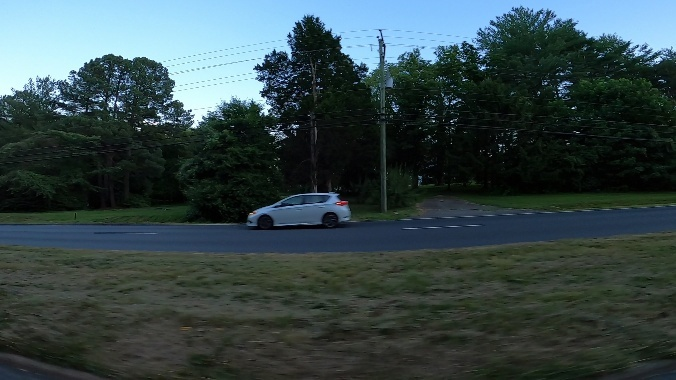

In [23]:
# [修改點 8] 視覺化：路徑改為 $EXP_NAME 對應圖

import os
from PIL import Image
from pathlib import Path

exp = os.environ.get("EXP_NAME", "exp")
cands = sorted(Path(f"runs/detect/{exp}").glob("*.jpg"))
print("EXP_NAME =", exp, f"，找到 {len(cands)} 張")

if cands:
    img = Image.open(cands[0])
else:
    fallback = Path("runs/detect/exp/0000000_00098_d_0000001.jpg")
    assert fallback.exists(), f"❌ 找不到偵測結果圖，請確認推論已完成（EXP_NAME={exp}）"
    img = Image.open(fallback)

display(img)

In [24]:
# [TRY3] 紀錄改走配置（update_workbook 參數由 yaml 的 val/detect 段來；note 自動帶 exp+hyp_override）
!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage record


EXP_YAML=/content/yolov3-car-detection/configs/experiments/car_640_e12.yaml
沿用既有 EXP_NAME=exp_20261001_212039_car_640_e12
BACKUP_DIR = /content/drive/MyDrive/YOLO_Experiments/exp_20261001_212039_car_640_e12
[record v6.0] EXP = exp_20261001_212039_car_640_e12
待寫入總表: {'實驗名稱': 'exp_20261001_212039_car_640_e12', '備份資料夾': 'YOLO_Experiments/exp_20261001_212039_car_640_e12', 'best.pt雲端路徑': 'YOLO_Experiments/exp_20261001_212039_car_640_e12/train/exp_20261001_212039_car_640_e12/weights/best.pt', '驗證iou': 0.65, '驗證用權重': 'best.pt', '推論conf': 0.25, '備註': 'exp=car_640_e12 hyp_override={}', 'P': 0.0128, 'R': 0.9626, 'mAP50': 0.4157, 'mAP50-95': 0.1122, 'train_box_loss': 0.0798, 'train_obj_loss': 0.0211, 'train_cls_loss': 0.0, 'val_box_loss': 0.067, 'val_obj_loss': 0.02, 'val_cls_loss': 0.0, 'epochs_done': 12, 'epochs': 12, 'batch': 16, 'imgsz': 640, 'cfg': 'models/yolov3.yaml', '資料集': 'Car-Object-Detection(1類)', '初始weights': '從零訓練(scratch)', 'lr0': 0.1, 'lrf': 0.1, 'momentum': 0.937, 'weight_decay':

# **Report**

## **Do it yourself**

Please use the YOLOv3 and another dataset to train your own object detection model.

Dataset: [Car Object Detection](https://www.kaggle.com/datasets/sshikamaru/car-object-detection)

You have to convert the annotations in csv to YOLOv3 format. ([ref](https://github.com/ultralytics/yolov3/wiki/Train-Custom-Data))

You also need to adjust hyperparameters to get better performance.

**Hint**:
1. hyp yaml file in *data/hyps* folder
  + search for a good learning rate (**lr0**) for the optimizer you use
  + **iou_t** should not be too large or too low

2. train.py
  + training by using more **epochs**

3. val.py & detect.py (if necessary)
  + try to adjust the **conf-thres** & **iou-thres** for better results and scores


